# Notebook Dedicated to Construct the Time Residual Distriburions of the Dataset 

In [1]:
import numpy as np
import glob
import os

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, ScalarFormatter
import seaborn as sn

# Load Data

In [2]:
# Directories
#main_dir = '/home/joankl/data/solars/real_data/bisMSB/first_candidates/ratds/analysis*/ratds_data/*.root'
main_dir = 'E:/Data/solars/mc/2p2PPO/solar_Nue/High Stat/np_files/hit_residual*.npy'
flist = glob.glob(main_dir)

time_res = np.array([]).astype(np.float32)

#Time residual cuts
time_res_inf_cut = -1.0
time_res_sup_cut = 50

for file_i in flist:

    print(f'reading File {file_i}')

    time_res_i = np.load(file_i).astype(np.float32)

    time_res_cut = (time_res_i >= time_res_inf_cut) & (time_res_i <= time_res_sup_cut)
    time_res_i = time_res_i[time_res_cut]

    time_res = np.append(time_res, time_res_i)

print('Done')

reading File E:/Data/solars/mc/2p2PPO/solar_Nue/High Stat/np_files\hit_residual_0.npy
reading File E:/Data/solars/mc/2p2PPO/solar_Nue/High Stat/np_files\hit_residual_10.npy
reading File E:/Data/solars/mc/2p2PPO/solar_Nue/High Stat/np_files\hit_residual_11.npy
reading File E:/Data/solars/mc/2p2PPO/solar_Nue/High Stat/np_files\hit_residual_12.npy
reading File E:/Data/solars/mc/2p2PPO/solar_Nue/High Stat/np_files\hit_residual_14.npy
reading File E:/Data/solars/mc/2p2PPO/solar_Nue/High Stat/np_files\hit_residual_15.npy
reading File E:/Data/solars/mc/2p2PPO/solar_Nue/High Stat/np_files\hit_residual_16.npy
reading File E:/Data/solars/mc/2p2PPO/solar_Nue/High Stat/np_files\hit_residual_17.npy
reading File E:/Data/solars/mc/2p2PPO/solar_Nue/High Stat/np_files\hit_residual_19.npy
reading File E:/Data/solars/mc/2p2PPO/solar_Nue/High Stat/np_files\hit_residual_2.npy
reading File E:/Data/solars/mc/2p2PPO/solar_Nue/High Stat/np_files\hit_residual_20.npy
reading File E:/Data/solars/mc/2p2PPO/solar_N

# Time Residual Plot

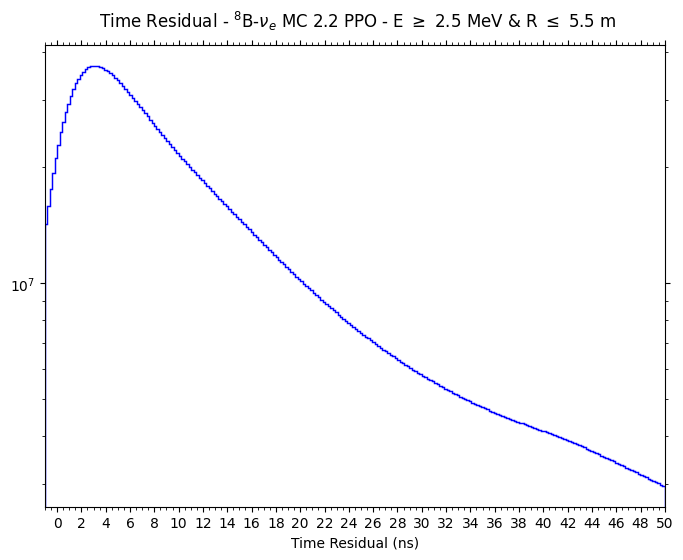

In [4]:
fig, ax = plt.subplots(figsize=(8,6))

bins = 250

#sn.histplot(time_res, bins = bins, element = 'step', alpha = 0, linewidth = 1.06)
counts, bin_edges = np.histogram(time_res, bins=bins, range=(min(time_res), max(time_res)))
ax.stairs(counts, bin_edges, color='blue', fill=False, linewidth=1.06)

plt.xlabel('Time Residual (ns)')
plt.title(rf' Time Residual - $^{{8}}$B-$\nu_e$ MC 2.2 PPO - E $\geq$ 2.5 MeV & R $\leq$ 5.5 m', y = 1.02)

plt.yscale('log')
plt.xlim(time_res_inf_cut, time_res_sup_cut)

ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.xaxis.set_major_locator(MultipleLocator(2))

ax.tick_params(which='minor', top=True, bottom=True, left=True, right=True)
ax.tick_params(which='major', top=True, bottom=True, left=True, right=True)

plt.show()